# Nama: Aldon Zufar Putra Twyn
# NIM: 4222301042
# Kelas: Robotika-B Pagi Semester-6
# Assignment-6: Unsupervised Learning - K-Means Clustering (WineQT Dataset)

In [25]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Dataset

In [26]:
df = pd.read_csv('WineQT.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## EDA (Exploratory Data Analysis)

Text(0.5, 1.0, 'Sebaran Nilai Fixed Acidity vs Volatile Acidity')

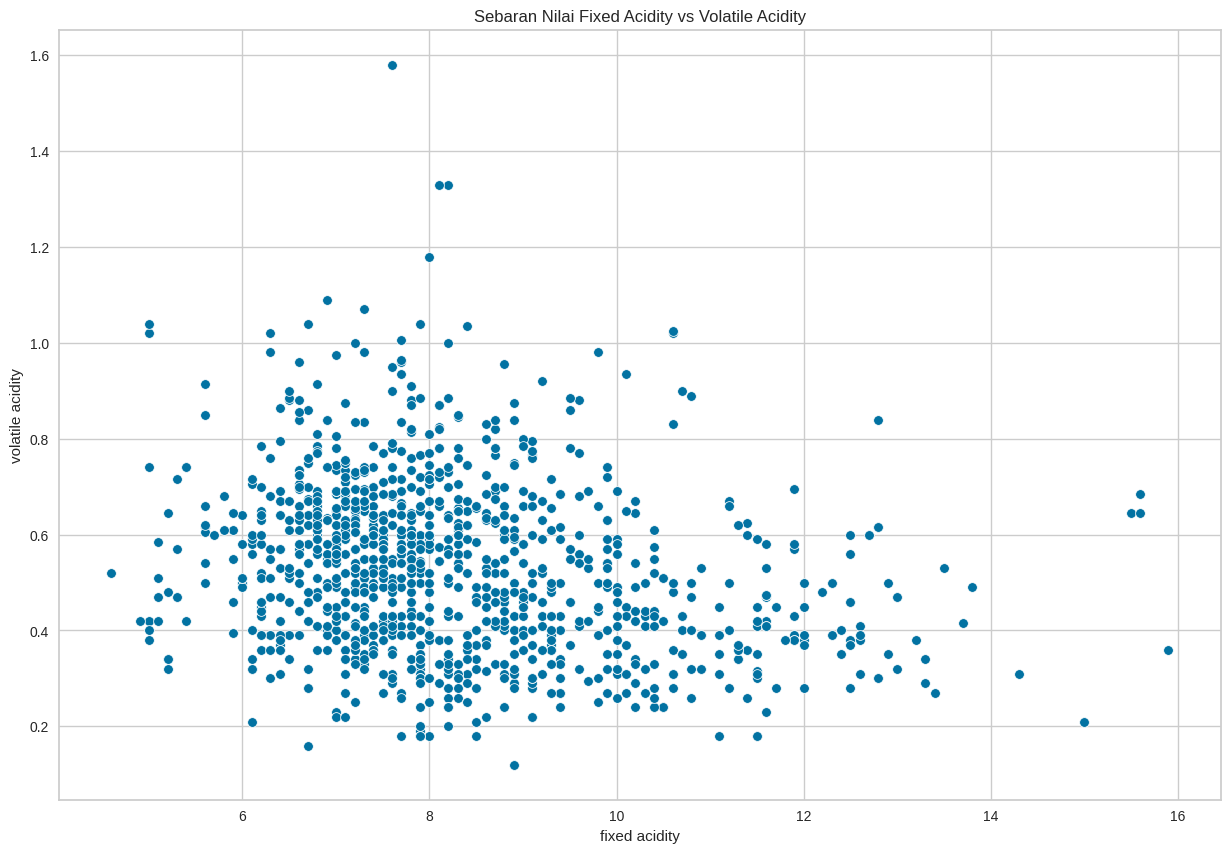

In [32]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed acidity', y='volatile acidity')
plt.title('Sebaran Nilai Fixed Acidity vs Volatile Acidity')

In [33]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


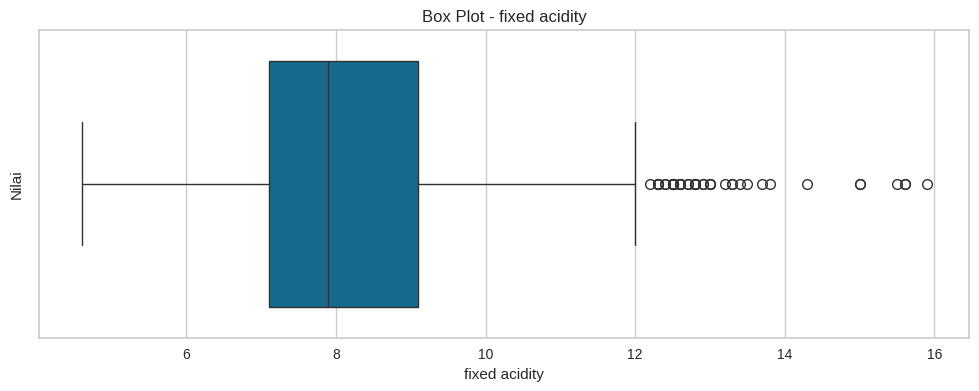

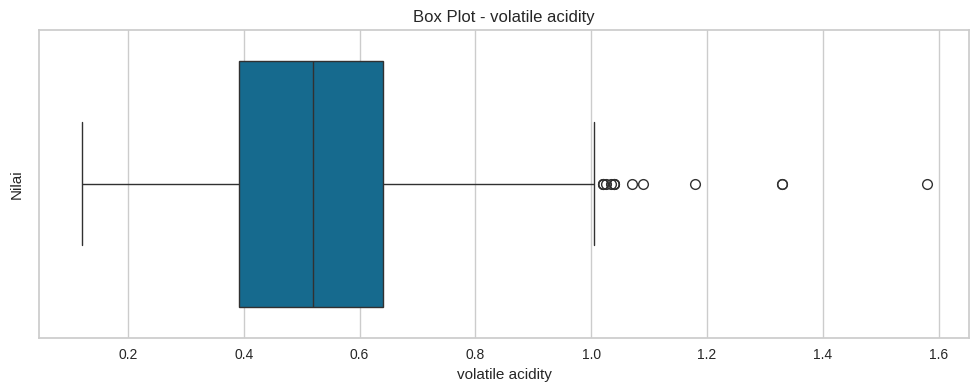

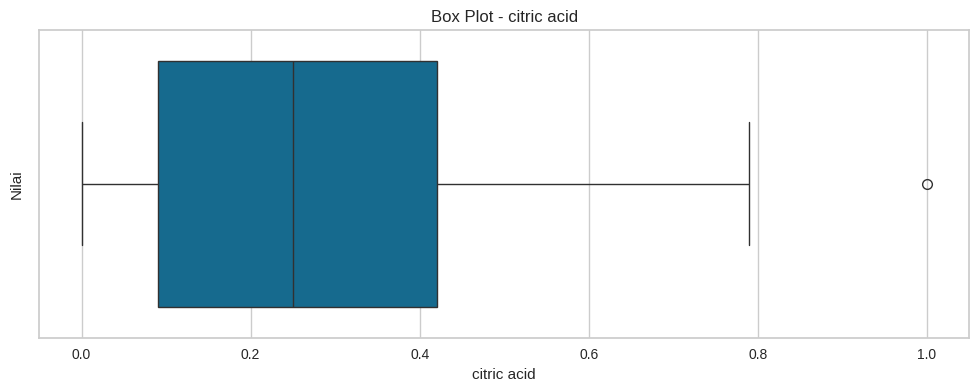

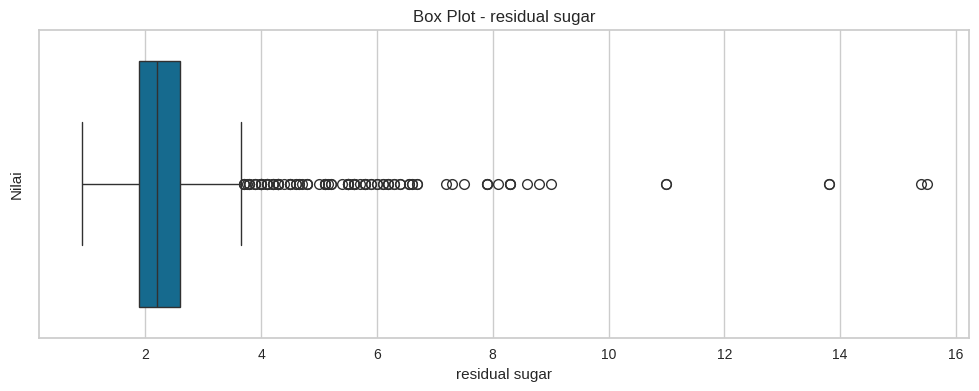

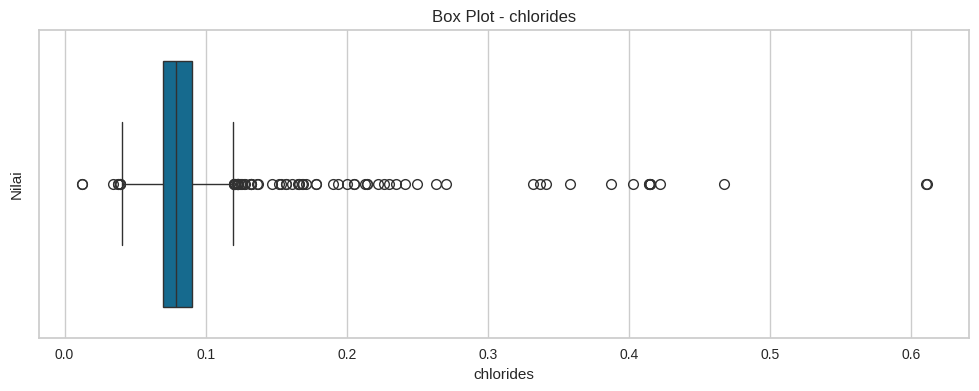

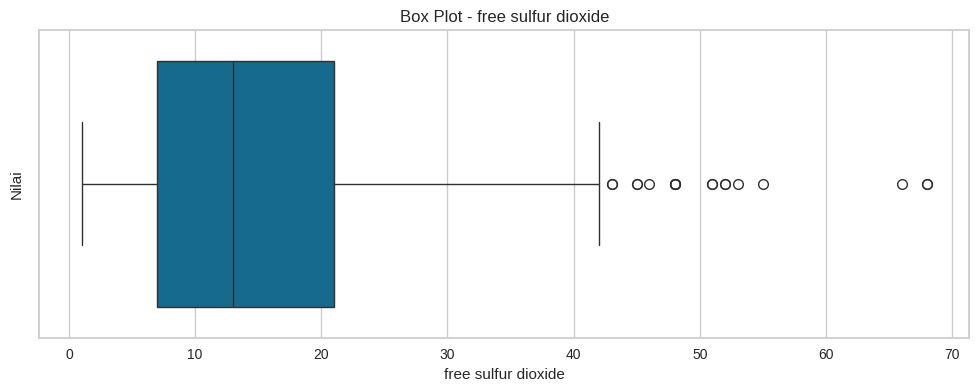

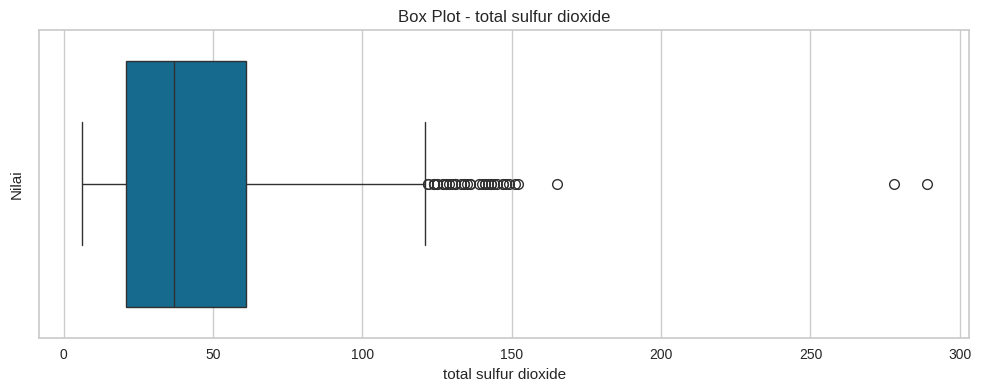

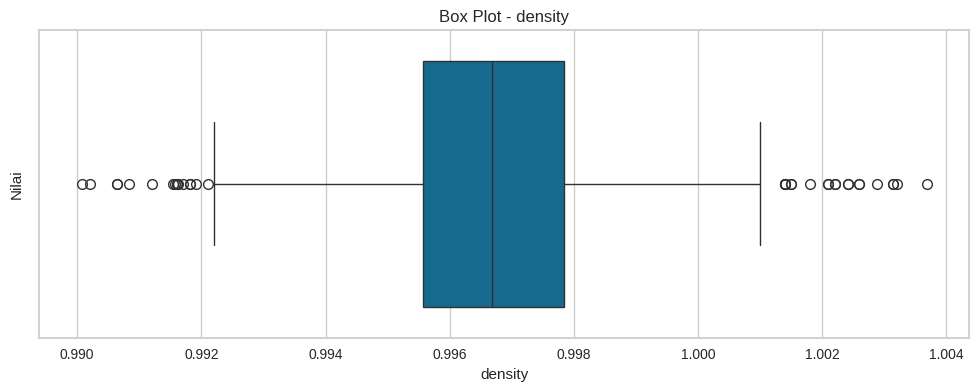

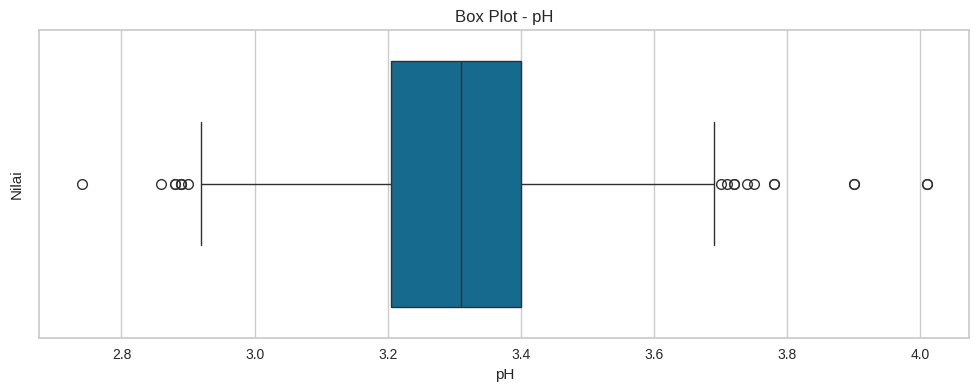

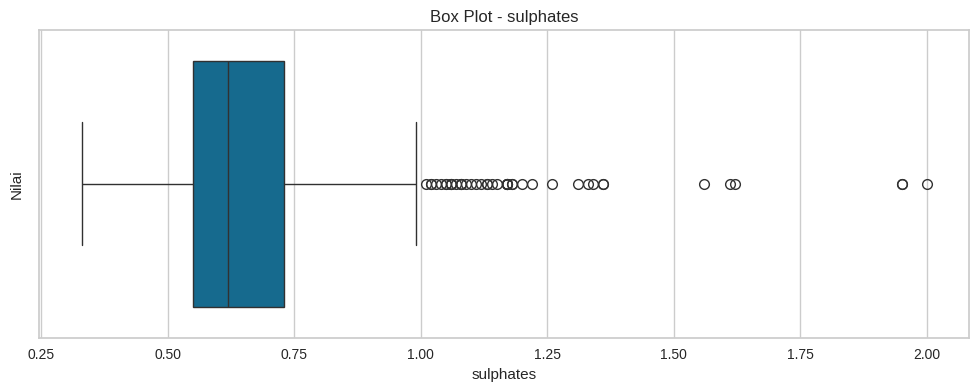

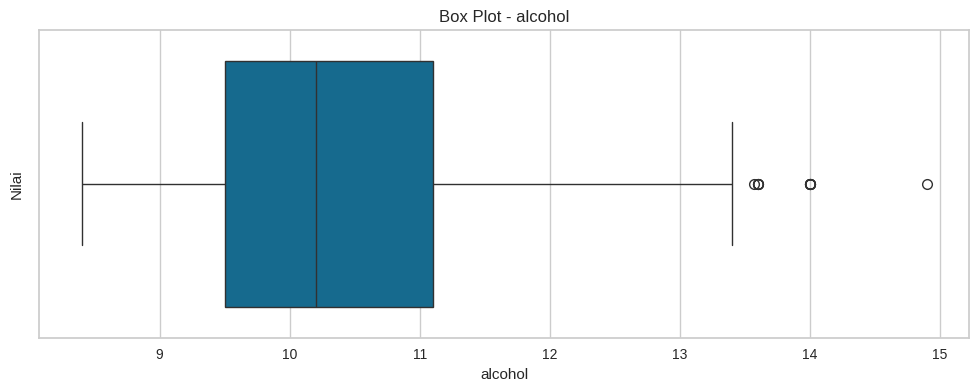

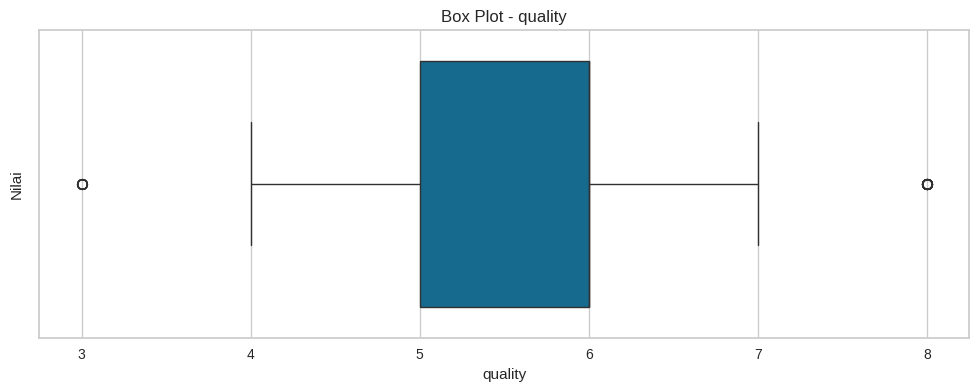

In [34]:
# Box plots untuk semua fitur numerik (kecuali Id)
feature_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
                'density', 'pH', 'sulphates', 'alcohol', 'quality']

for col in feature_cols:
    plt.figure(figsize=(12, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

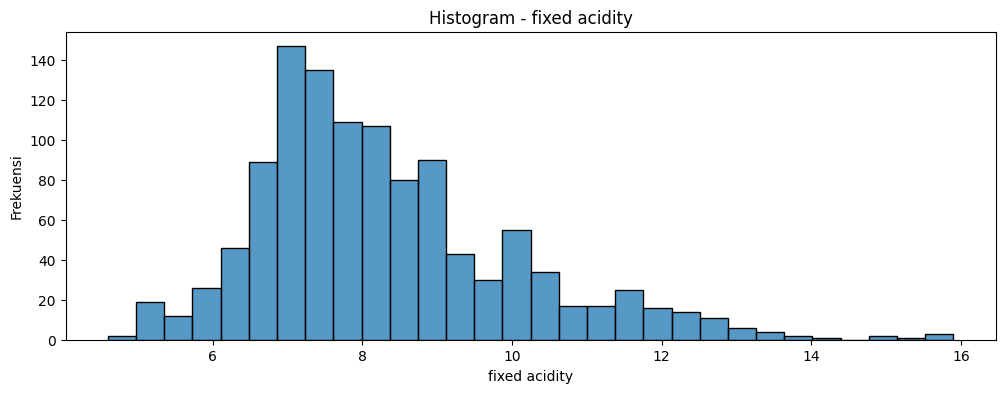

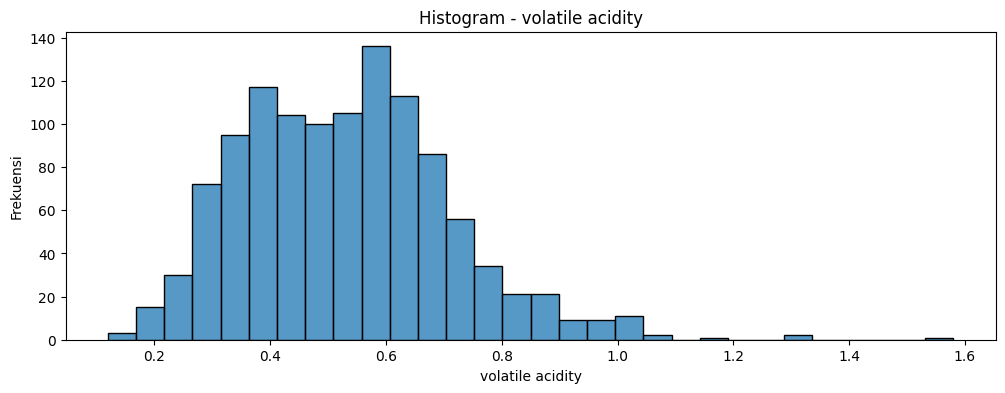

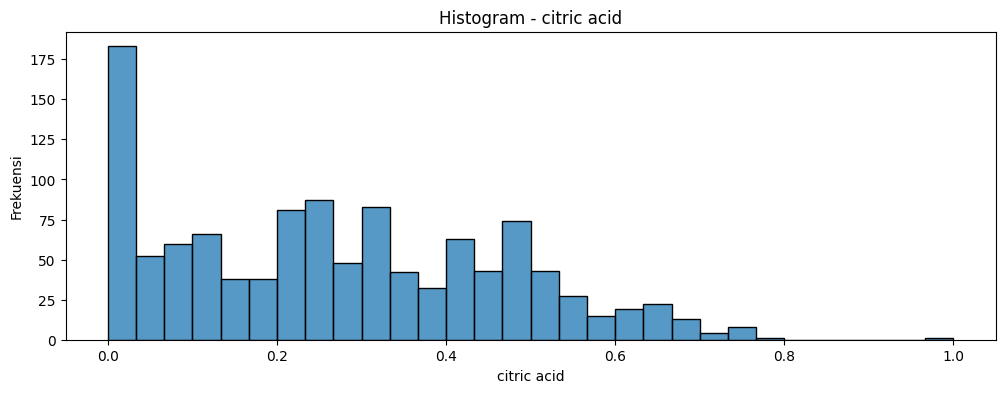

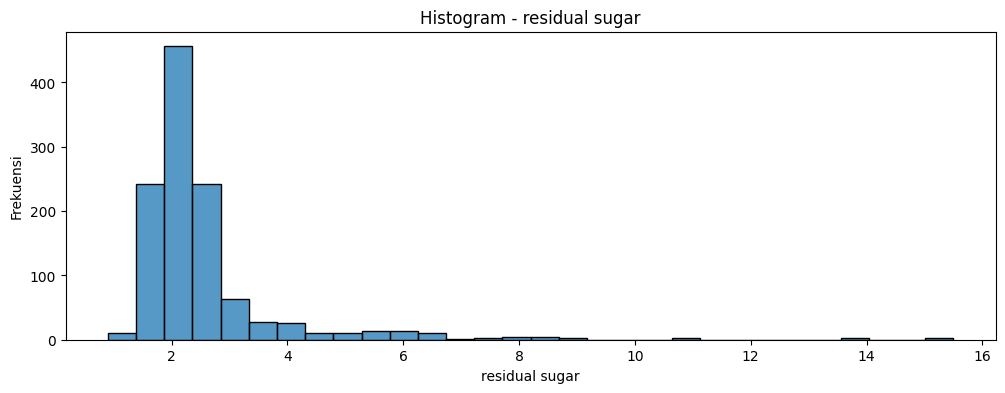

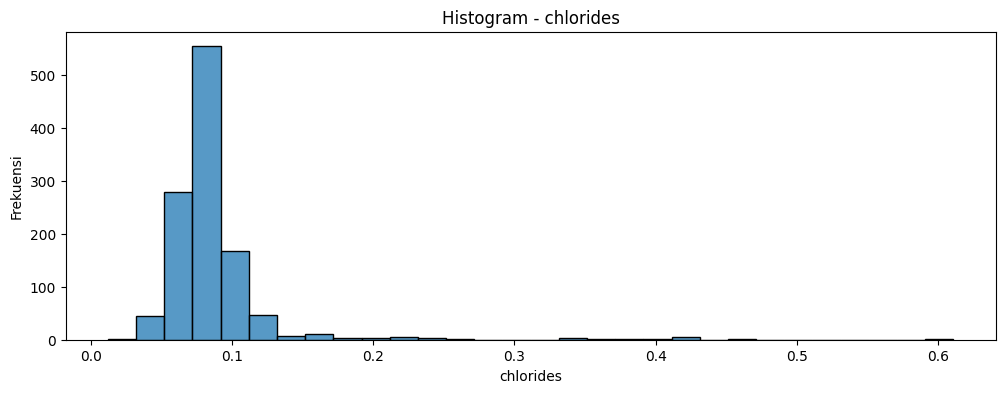

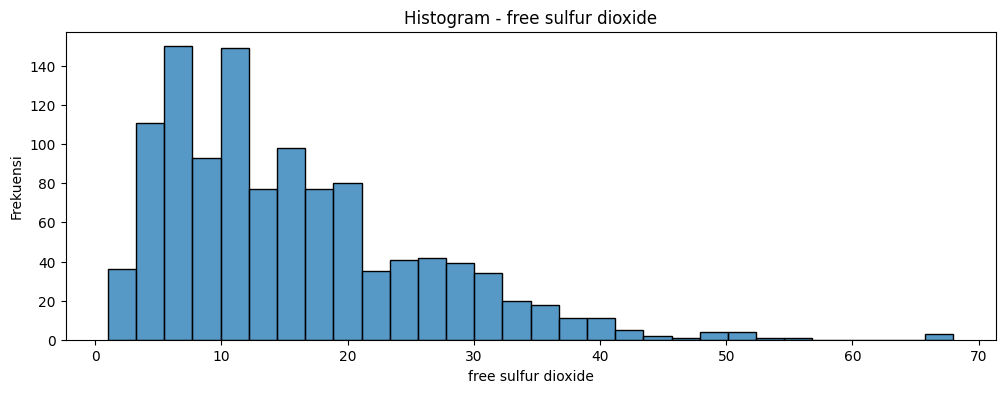

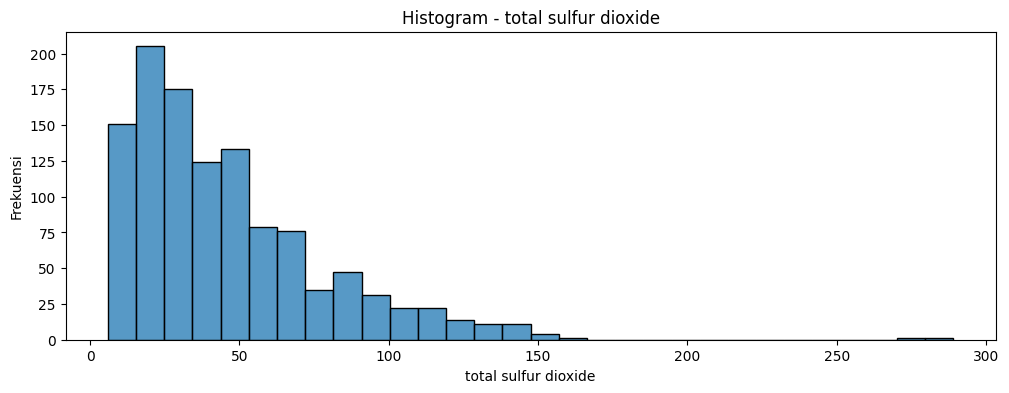

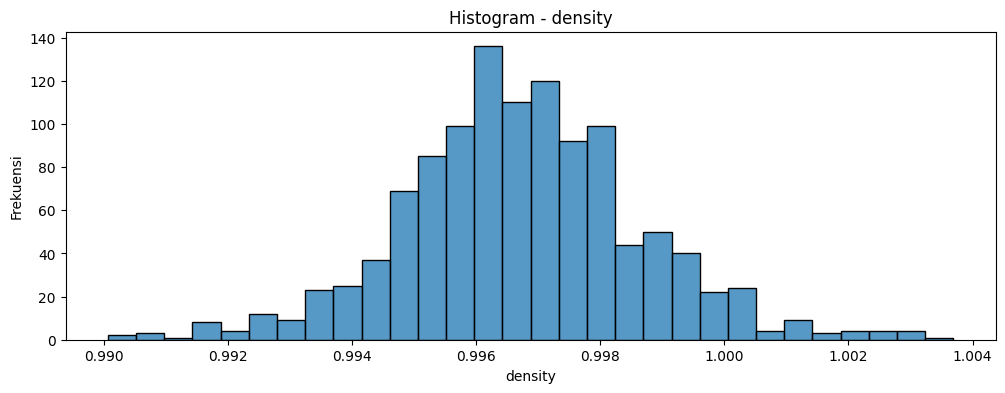

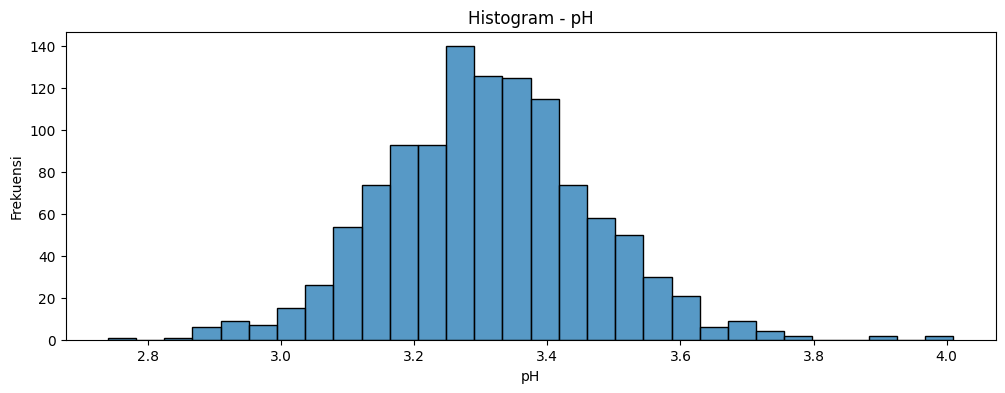

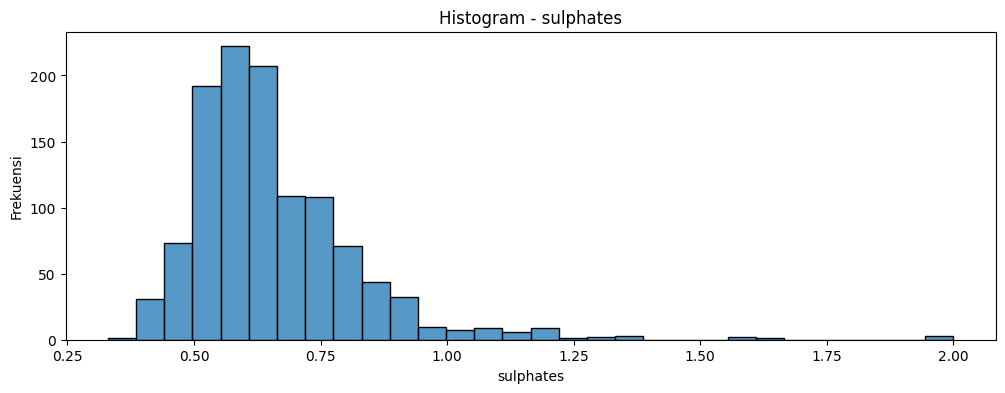

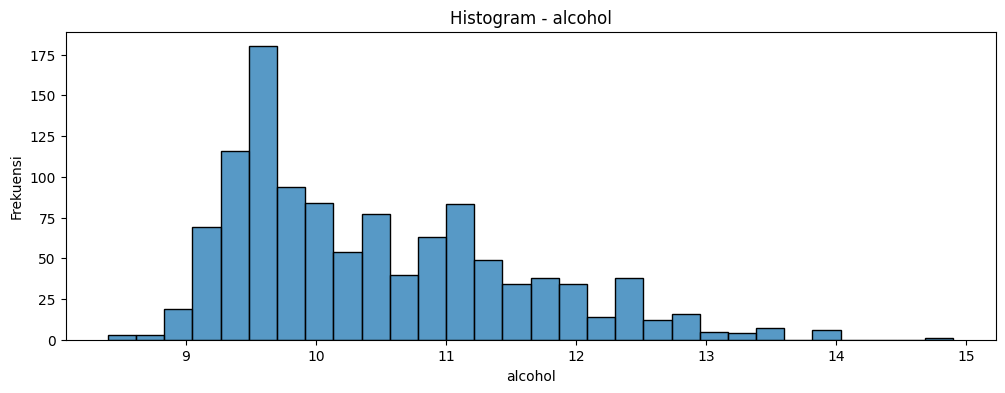

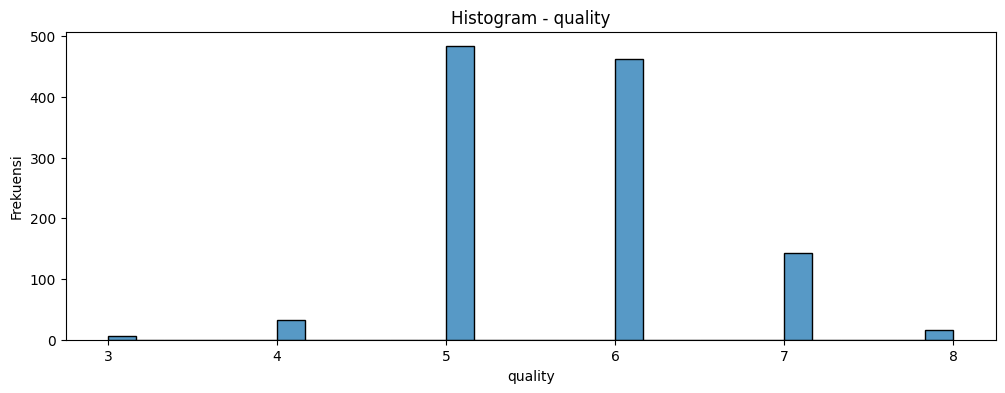

In [ ]:
for col in feature_cols:
    plt.figure(figsize=(12, 4))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

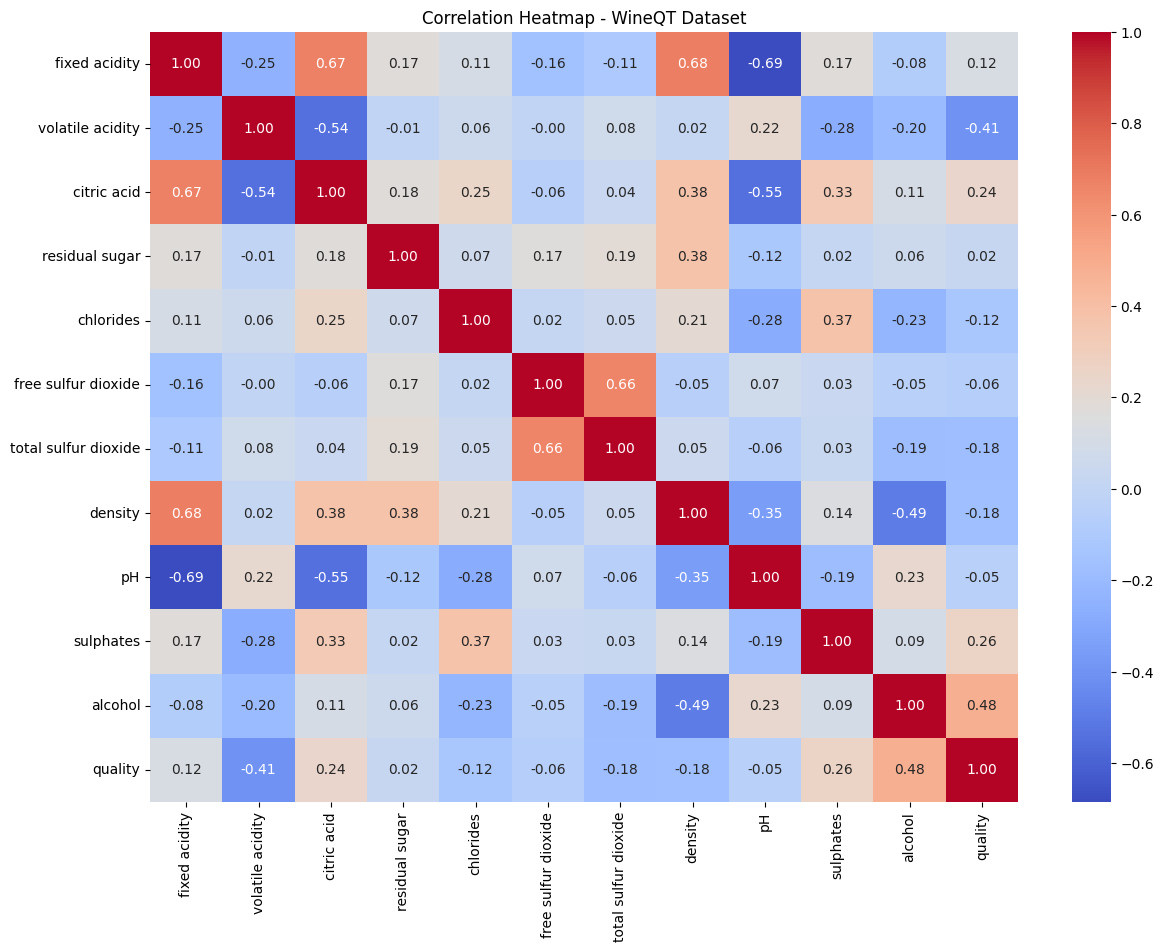

In [7]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df[feature_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - WineQT Dataset')
plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Drop kolom Id (tidak relevan untuk clustering)
3. Outlier Handling (opsional)
4. Feature Scaling

In [ ]:
# Drop Duplicates

print(f"Dimensi dataframe sebelum drop duplikat: {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dimensi dataframe setelah drop duplikat: {df.shape[0]}")

Dimensi dataframe sebelum drop duplikat: 1143
Dimensi dataframe setelah drop duplikat: 1143


dari hasil running program diatas, tidak ada data yg duplikat karena jumlah tetap sama


In [37]:
# Drop kolom 'Id' karena tidak relevan untuk clustering
df = df.drop(columns=['Id'])
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# Gunakan semua fitur numerik untuk clustering
fitur_columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
                 'density', 'pH', 'sulphates', 'alcohol']

X = df[fitur_columns].values
y = df['quality'].values  # anotator (kualitas wine) (+ self reminder fix column fitur atas)

In [38]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scaling = pd.DataFrame(data=X_std, columns = fitur_columns)
df_scaling.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03
mean,-3.729883e-16,4.475860e-16,2.486589e-17,1.554118e-16,8.081413e-17,-5.594825e-17,9.946355e-17,5.783805e-14,-8.454402e-16,4.973178e-17,-1.193563e-15
std,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00
min,-2.124483e+00,-2.290883e+00,-1.365027e+00,-1.204252e+00,-1.585988e+00,-1.426458e+00,-1.218108e+00,-3.461348e+00,-3.646432e+00,-1.924024e+00,-1.887834e+00
25%,-6.933192e-01,-7.732388e-01,-9.072439e-01,-4.664214e-01,-3.583880e-01,-8.408632e-01,-7.603412e-01,-6.030539e-01,-6.769982e-01,-6.323694e-01,-8.709366e-01
50%,-2.353469e-01,-6.314838e-02,-9.340780e-02,-2.450722e-01,-1.678983e-01,-2.552689e-01,-2.720568e-01,-2.619819e-02,-6.480857e-03,-2.213884e-01,-2.238203e-01
75%,4.516116e-01,6.051720e-01,7.712930e-01,5.006018e-02,6.492241e-02,5.255235e-01,4.603699e-01,5.792404e-01,5.682483e-01,4.244390e-01,6.081863e-01
max,4.344377e+00,5.840349e+00,3.721449e+00,9.568078e+00,1.109216e+01,5.112679e+00,7.418423e+00,3.616827e+00,4.463634e+00,7.880809e+00,4.121103e+00


In [39]:
X_std

array([[-0.52157961,  0.93933222, -1.36502663, ...,  1.27069495,
        -0.57365783, -0.96338181],
       [-0.29259344,  1.94181282, -1.36502663, ..., -0.70892755,
         0.1308811 , -0.59360107],
       [-0.29259344,  1.27349242, -1.16156762, ..., -0.32577481,
        -0.04525363, -0.59360107],
       ...,
       [-1.20853813,  0.38239855, -0.9581086 , ...,  0.88754221,
        -0.45623467,  0.05351522],
       [-1.38027776,  0.10393172, -0.8563791 , ...,  1.33455374,
         0.60057372,  0.70063152],
       [-1.38027776,  0.6330187 , -0.75464959, ...,  1.65384769,
         0.30701583, -0.22382033]], shape=(1143, 11))

In [41]:
df_scaling

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
...,...,...,...,...,...,...,...,...,...,...,...
1138,-1.151292,-0.118842,-0.703785,-0.171289,-0.231395,1.306316,-0.180503,-0.514707,0.695966,0.541862,0.515741
1139,-0.865059,0.493785,-0.958109,-0.466421,-0.400719,1.208717,-0.241539,-0.114545,0.695966,0.952843,-0.870937
1140,-1.208538,0.382399,-0.958109,-0.392638,0.064922,1.599113,-0.058432,-0.951246,0.887542,-0.456235,0.053515
1141,-1.380278,0.103932,-0.856379,-0.245072,-0.527712,2.282306,0.155192,-0.836914,1.334554,0.600574,0.700632


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

### Distribusi Sebelum dan Setelah Feature Scaling

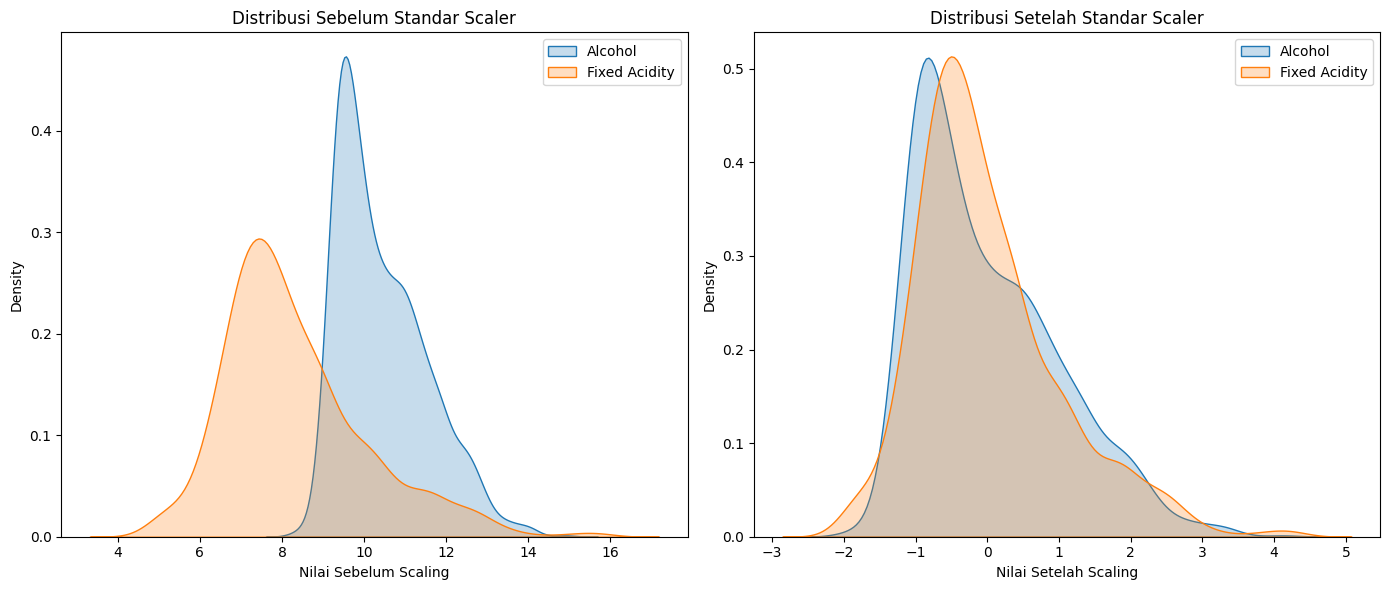

In [12]:
# Cek distribusi sebelum dan setelah scaling
# Pilih 2 fitur representatif: alcohol dan fixed acidity
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 6))

# Sebelum Scaling
ax1.set_title('Distribusi Sebelum Standar Scaler')
sns.kdeplot(df['alcohol'], ax=ax1, label='Alcohol', fill=True)
sns.kdeplot(df['fixed acidity'], ax=ax1, label='Fixed Acidity', fill=True)
ax1.set_xlabel('Nilai Sebelum Scaling')
ax1.legend()

# Setelah Scaling
ax2.set_title('Distribusi Setelah Standar Scaler')
sns.kdeplot(df_scaling['alcohol'], ax=ax2, label='Alcohol', fill=True)
sns.kdeplot(df_scaling['fixed acidity'], ax=ax2, label='Fixed Acidity', fill=True)
ax2.set_xlabel('Nilai Setelah Scaling')
ax2.legend()

plt.tight_layout()
plt.show()

### Interpretasi Distribusi Sebelum dan Setelah Scaling:
Sebelum dilakukan scaling, setiap fitur memiliki range nilai yang berbeda-beda. Misalnya total sulfur dioxide bisa bernilai hingga ratusan, sedangkan density berkisar di angka 0.99. Perbedaan skala ini dapat menyebabkan fitur dengan range besar mendominasi proses clustering.

Setelah menggunakan StandardScaler, semua fitur memiliki distribusi dengan mean = 0 dan standar deviasi = 1, sehingga setiap fitur berkontribusi secara seimbang dalam proses K-Means clustering.

## K-Means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik:
1. Metode Elbow
2. Via-Score Plot

### 1. Metode Elbow

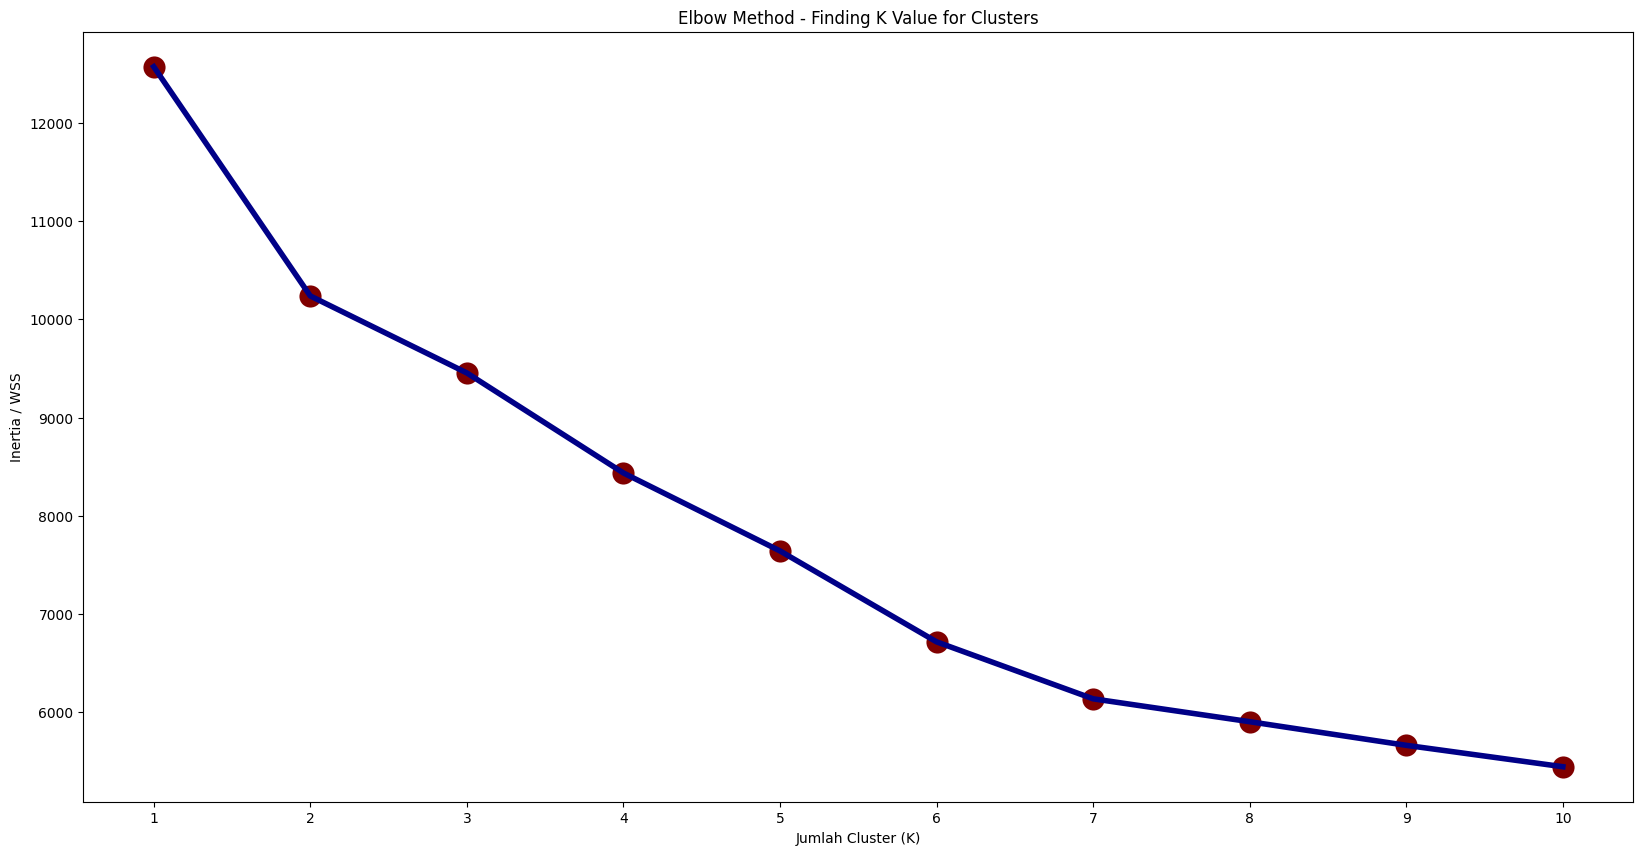

In [13]:
from sklearn.cluster import KMeans

inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scaling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))
sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth=4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000')
plt.title('Elbow Method - Finding K Value for Clusters')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia / WSS')
plt.xticks(range(1, 11))
plt.show()

In [43]:
# Dari grafik Elbow, dipilih K=3
# karena di titik tersebut terjadi "lekukan" (elbow) yang menandakan
# penurunan inertia mulai melambat secara signifikan

from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=3, random_state=0)
kmeans_elbow.fit(df_scaling.values)

# Simpan hasil cluster ke dataframe
df['cluster_elbow'] = kmeans_elbow.labels_
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster_elbow
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,2
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


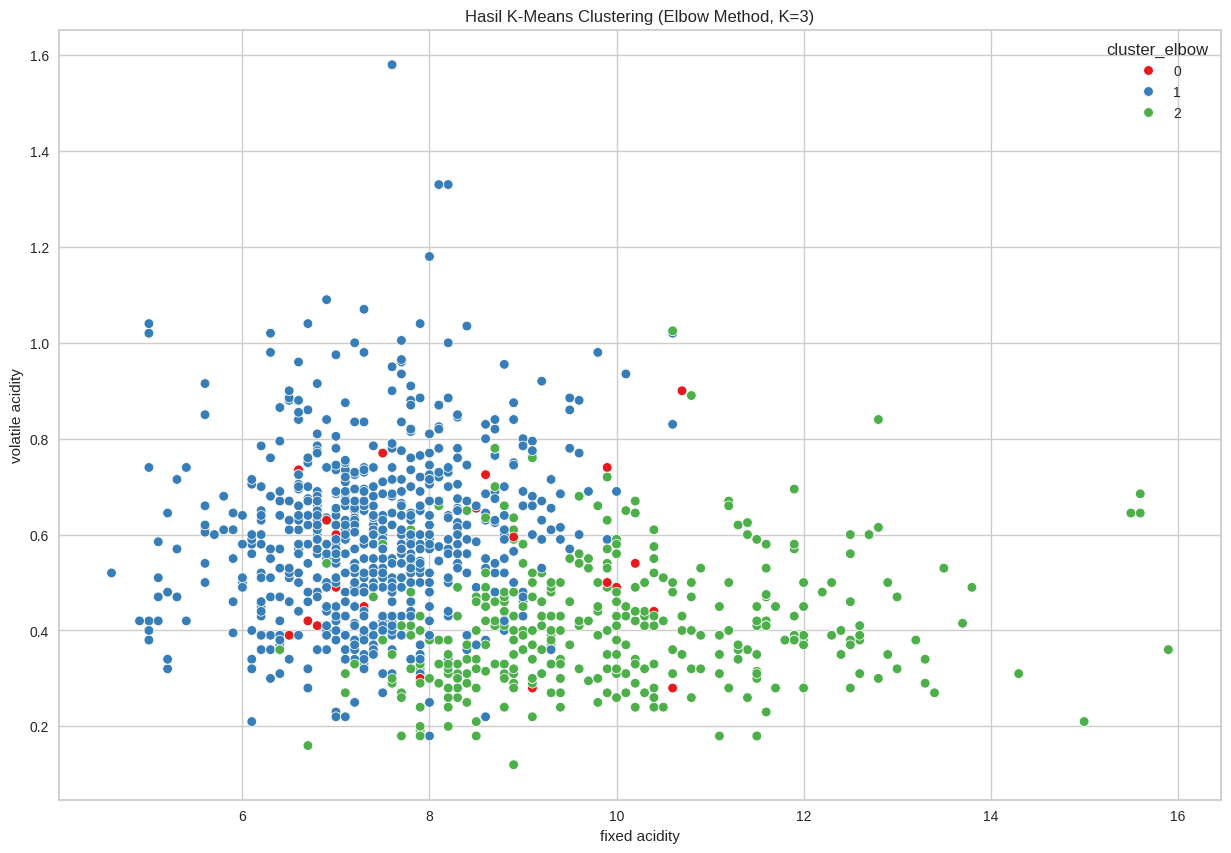

In [45]:
# Visualisasi hasil clustering Elbow (fixed acidity vs volatile acidity)
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df, x='fixed acidity', y='volatile acidity', hue='cluster_elbow', palette='Set1')
plt.title('Hasil K-Means Clustering (Elbow Method, K=3)')
plt.show()

### Bandingkan dengan Label Anotator (Quality)

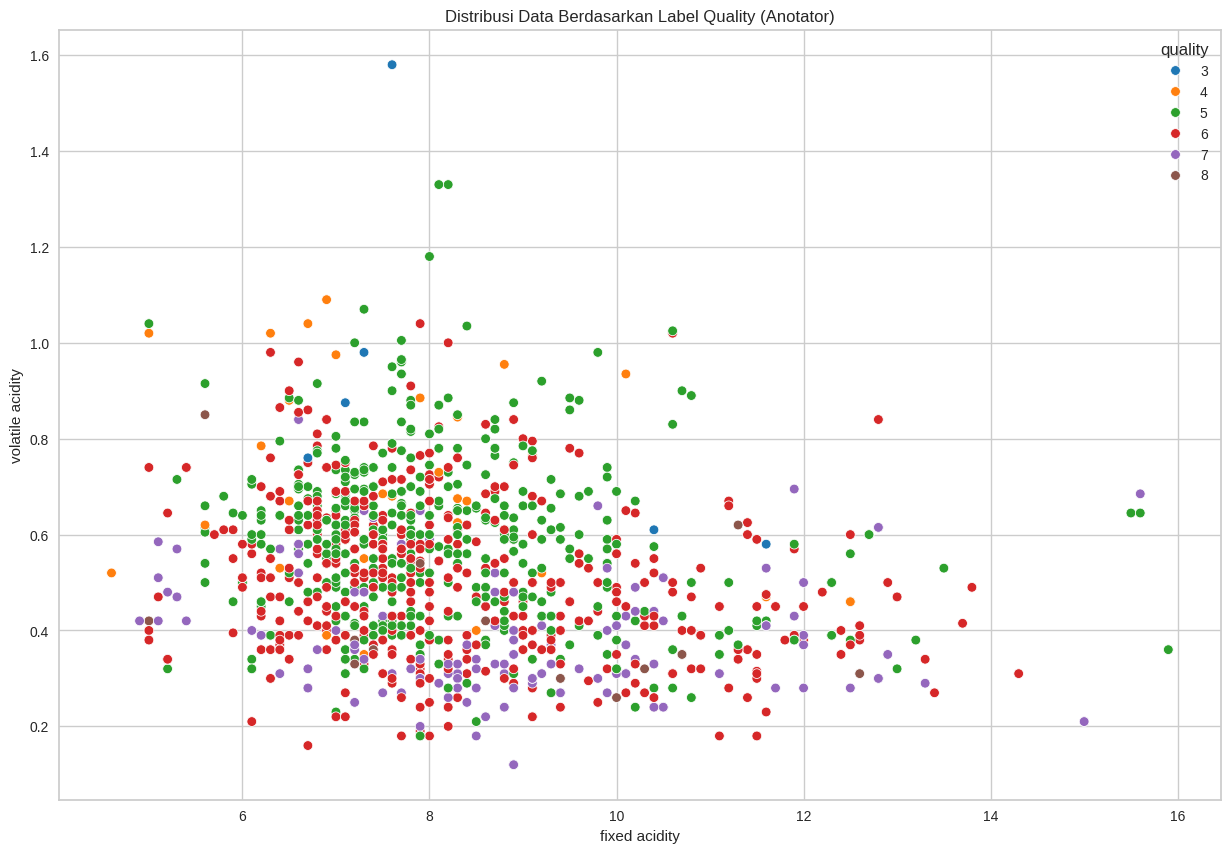

In [46]:
# Visualisasi distribusi asli berdasarkan quality label
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df, x='fixed acidity', y='volatile acidity', hue='quality', palette='tab10')
plt.title('Distribusi Data Berdasarkan Label Quality (Anotator)')
plt.show()

### Interpretasi Hasil Elbow Method:
Dari hasil Elbow Method, dipilih K=3 karena pada titik tersebut terjadi "siku" (elbow) yang paling jelas, yaitu penurunan inertia mulai tidak signifikan setelah K=3.

Hasil clustering dengan K=3 mengelompokkan wine ke dalam 3 kelompok berdasarkan kesamaan karakteristik kimiawi:
- **Cluster 0**: Wine dengan kadar alkohol rendah-sedang dan kualitas menengah
- **Cluster 1**: Wine dengan karakteristik keasaman tinggi
- **Cluster 2**: Wine dengan kadar alkohol tinggi cenderung berkualitas lebih baik

### 2. Via-Score Plot

In [17]:
!pip install yellowbrick -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


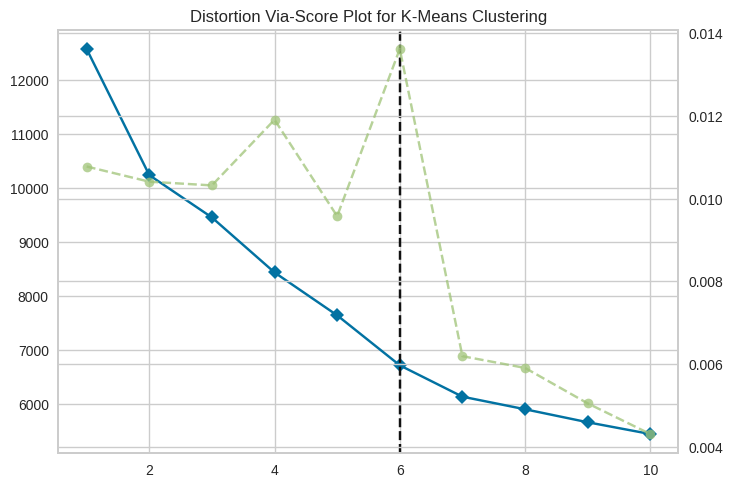

In [48]:
from yellowbrick.cluster import KElbowVisualizer

k_means_via = KMeans(random_state=0)
visualizer = KElbowVisualizer(k_means_via, k=(1, 11), timings=True, force_model=True)
visualizer.fit(df_scaling.values)
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [49]:
# Dari Via-Score Plot, gunakan K yang ditentukan oleh visualizer
# (umumnya akan menunjukkan K=3 atau sesuai hasil plot)
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0)
kmeans_via.fit(df_scaling.values)

# Simpan hasil cluster ke dataframe
df['cluster_via'] = kmeans_via.labels_
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster_elbow,cluster_via
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,2,2
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1,1


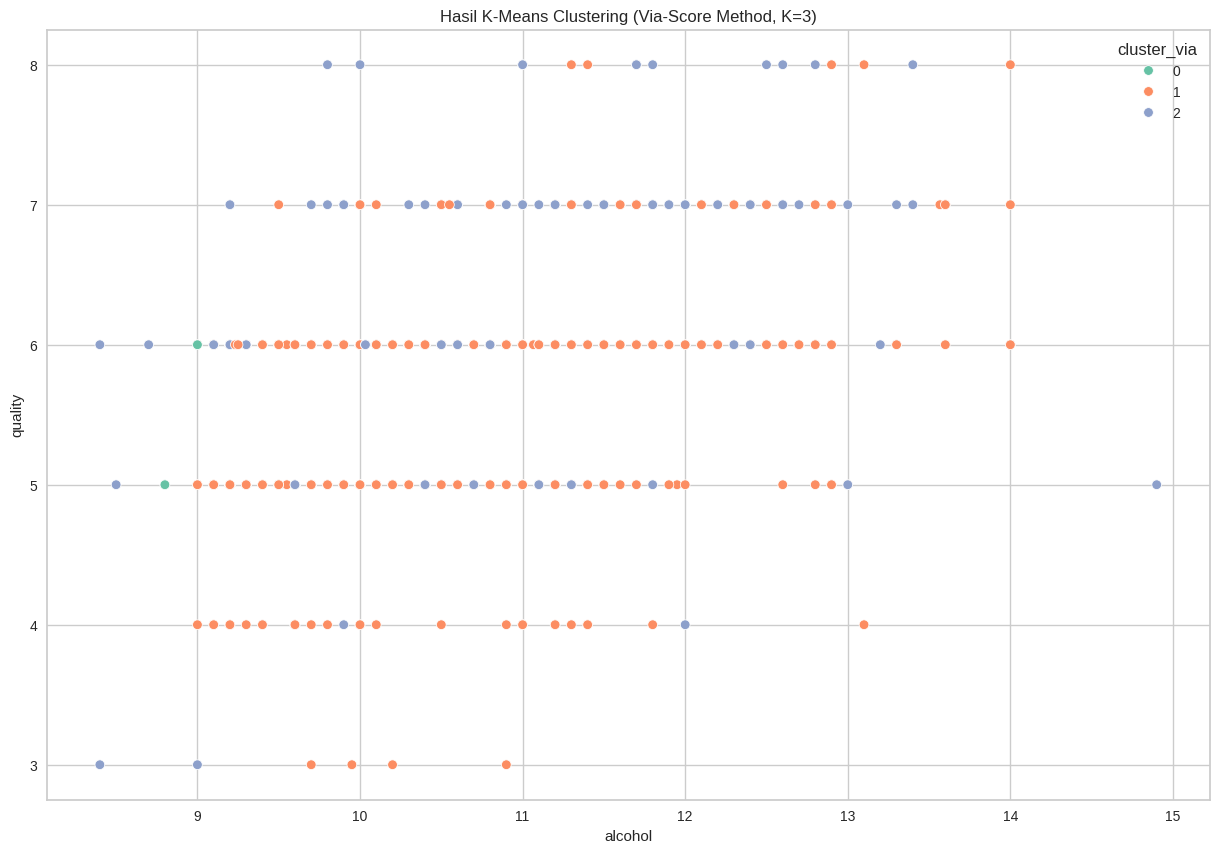

In [50]:
# Evaluasi visualisasi cluster via score
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='cluster_via', palette='Set2')
plt.title('Hasil K-Means Clustering (Via-Score Method, K=3)')
plt.show()

### Bandingkan dengan Label Anotator

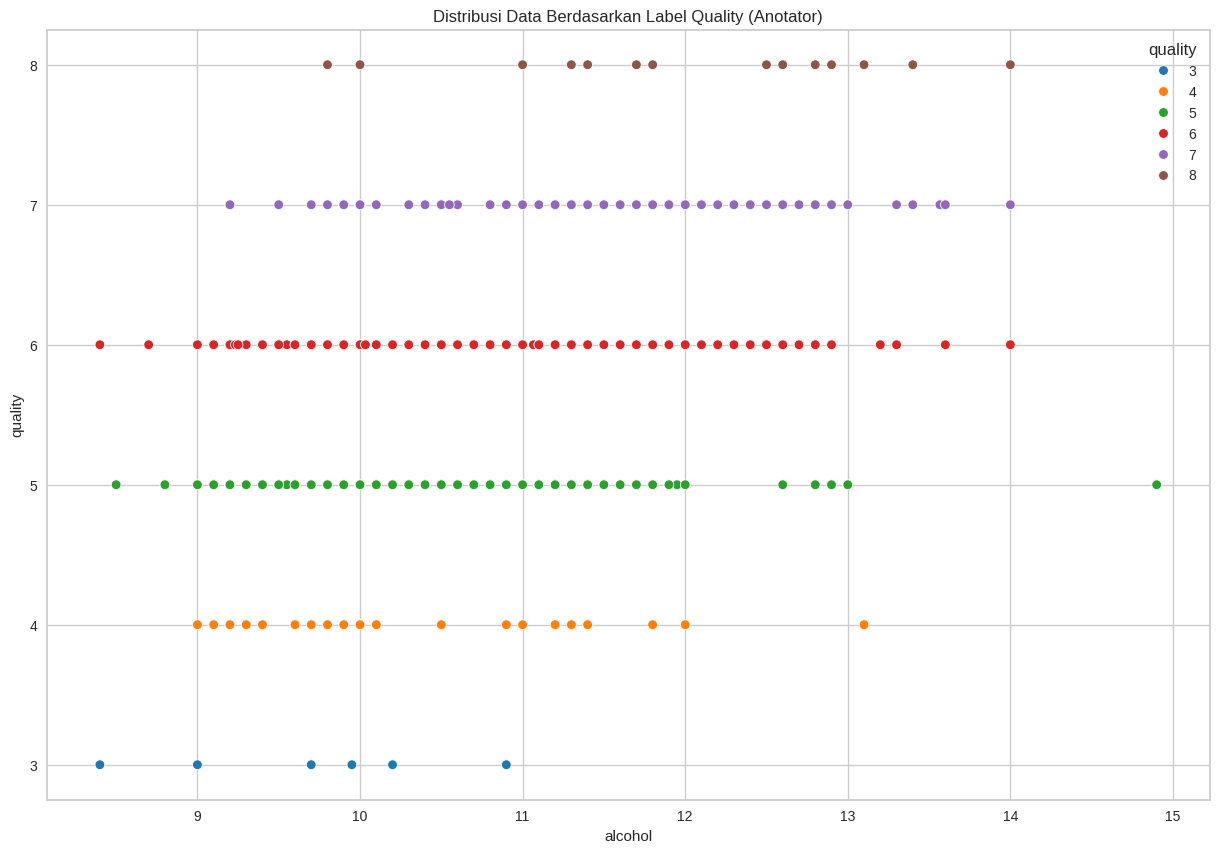

In [51]:
# Perbandingan dengan label quality (anotator)
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df, x='alcohol', y='quality', hue='quality', palette='tab10')
plt.title('Distribusi Data Berdasarkan Label Quality (Anotator)')
plt.show()

In [22]:
# Tampilkan jumlah data per cluster
print("Distribusi cluster (Elbow):")
print(df['cluster_elbow'].value_counts())

print()
print("Distribusi cluster (Via-Score):")
print(df['cluster_via'].value_counts())

print()
print("Distribusi quality asli:")
print(df['quality'].value_counts().sort_index())

Distribusi cluster (Elbow):
cluster_elbow
1    720
2    390
0     33
Name: count, dtype: int64

Distribusi cluster (Via-Score):
cluster_via
1    720
2    390
0     33
Name: count, dtype: int64

Distribusi quality asli:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


### Interpretasi Hasil Via-Score Method:

1. **Proses clustering berhasil** mengelompokkan data wine ke dalam cluster berdasarkan kemiripan karakteristik kimia (kadar alkohol, keasaman, sulfur, dll), bukan berdasarkan label quality secara langsung — sesuai dengan sifat unsupervised learning.

2. **Cluster 0** mengelompokkan wine dengan karakteristik kimia tertentu, misalnya kadar alkohol sedang dan total sulfur dioxide tinggi.

3. **Cluster 1** mengelompokkan wine dengan keasaman yang lebih tinggi (volatile acidity & fixed acidity lebih besar).

4. **Cluster 2** mengelompokkan wine dengan kadar alkohol lebih tinggi yang umumnya berkorelasi dengan kualitas yang lebih baik.

5. Meskipun label `quality` tidak digunakan saat training, terdapat keterkaitan antara hasil cluster dan distribusi quality — ini menunjukkan bahwa fitur kimia memiliki pola yang berkorelasi dengan kualitas wine secara alami.

### Thank you :)